# HQFr Demo - Hybrid Quantum Neural Network

This notebook demonstrates the complete HQFr pipeline for CaF₂/CaF₂:Er spectral classification using Hybrid Quantum classical model

## Architecture
```
Input (3 features) → PreQuantumNN (3→3) → QuantumLayer (3 qubits, 4 layers) → PostQuantumNN (9→16→1) → Output
```

## Features Used
1. α (Absorption cm^-1)
2. κ (Extinction coeff)
3. Energy (eV)

In [8]:
# =====================================================
# Setup script to add the project root to the Python path
# =====================================================
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent  # Go up 2 levels

# If running from a different directory, try to find it
if not (project_root / "qiskit_qml").exists():
    # Try current directory
    project_root = Path.cwd()
    while (
        not (project_root / "qiskit_qml").exists()
        and project_root != project_root.parent
    ):
        project_root = project_root.parent

if (project_root / "qiskit_qml").exists():
    sys.path.insert(0, str(project_root))
    print(f"✓ Added to Python path: {project_root}")
else:
    print("⚠️ Could not find project root. Please run from Q-UCSpec directory.")
    print(f"Current directory: {Path.cwd()}")

⚠️ Could not find project root. Please run from Q-UCSpec directory.
Current directory: /Users/ragunathchandrasekharan/Documents/Documents/Masters/Quantum Computing/qiskit-advocate/projects/QAMP/QUCSpec/code/refined/HQFr/hqfr


In [9]:
# Setup
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

# Set seed for reproducibility
from config import SEED, set_seed

set_seed(SEED)

# Force float64 for precision
torch.set_default_dtype(torch.float64)


print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch: 2.5.1
NumPy: 1.26.4
Device: cpu


## 1. Data Preprocessing & Visualization

In [10]:
from preprocessing import FEATURE_COLUMNS, load_and_preprocess

# Load data
X_train, X_val, X_test, y_train, y_val, y_test, transformer, pos_weight = (
    load_and_preprocess()
)

HQFr DATA PREPROCESSING

Dataset loaded:
  Train: 2016 samples
  Val:   432 samples
  Test:  433 samples

Features (3):
    1. α (Absorption cm^-1)
    2. κ (Extinction coeff)
    3. Energy (eV)

Class distribution (train): [ 904 1112]
Pos weight: 0.8131
Preprocessing: StandardScaler (zero-mean, unit-variance)


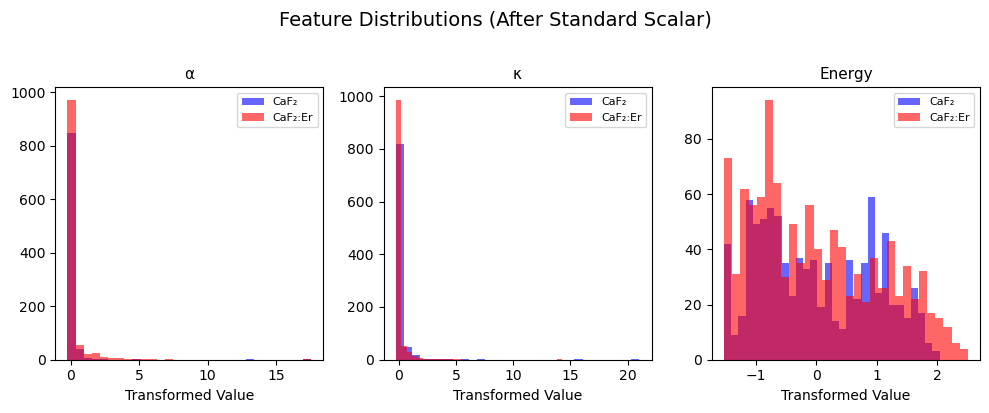

In [11]:
# Visualize feature distributions
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, FEATURE_COLUMNS)):
    ax.hist(X_train[y_train == 0, i], bins=30, alpha=0.6, label="CaF₂", color="blue")
    ax.hist(X_train[y_train == 1, i], bins=30, alpha=0.6, label="CaF₂:Er", color="red")
    ax.set_title(name.split("(")[0].strip(), fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel("Transformed Value")

plt.suptitle("Feature Distributions (After Standard Scalar)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

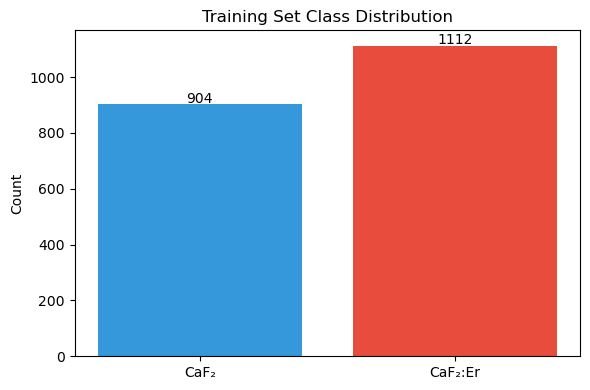

Class imbalance ratio: 0.813
Pos weight for loss: 0.8131


In [12]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["CaF₂", "CaF₂:Er"]
counts = [sum(y_train == 0), sum(y_train == 1)]
bars = ax.bar(labels, counts, color=["#3498db", "#e74c3c"])
ax.set_ylabel("Count")
ax.set_title("Training Set Class Distribution")
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count), ha="center"
    )
plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {counts[0] / counts[1]:.3f}")
print(f"Pos weight for loss: {pos_weight:.4f}")

## 2. Data Loading

In [13]:
from config import BATCH_SIZE
import torch
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float64),
    torch.tensor(y_train, dtype=torch.float64),
)
val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float64),
    torch.tensor(y_val, dtype=torch.float64),
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float64),
    torch.tensor(y_test, dtype=torch.float64),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Model Architecture

In [14]:
from hqfr_model import HQFr
from config import POST_NN_HIDDEN

# Initialize HQFr model
model = HQFr(post_nn_hidden=POST_NN_HIDDEN)

✓ PreQuantumNN initialized
    Architecture: 3→3
    Parameters: 12
✓ Quantum device: default.qubit (CPU)
✓ EnhancedQuantumLayer initialized
    Qubits: 3
    Layers: 4
    Embedding: Angle (1st-order)
    Repeats: 3
    Observables: X,Y,Z (3x)
    Initialization: uniform
    Entanglement: [1, 1, 2, 2]
    Parameters: 36
    Output dim: 9
✓ PostQuantumNN initialized
    Architecture: 9→16→1
    Dropout: 0.15
    Output: Raw logits (use BCEWithLogitsLoss)

HQFr INITIALIZED (Pretrain-Frozen Strategy)
  Pre-NN params:       12
  Quantum params:      36
  Post-NN params:     209
  Circuit gain:      1
  -----------------------------------
  Total params:       258
  Initial QG value:  1.0

  Training Strategy:
    Phase 1: Classical pre-training (quantum frozen)
    Phase 2: Quantum training (classical frozen)



# Training

In [15]:
# Train with 2-phase strategy

from train_hqfr import train_hqfr, evaluate
from config import EPOCHS_PHASE1, EPOCHS_PHASE2, LR_PRE, LR_POST

history = train_hqfr(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    pos_weight=pos_weight,
    epochs_phase1=EPOCHS_PHASE1,
    epochs_phase2=EPOCHS_PHASE2,
    lr_pre=LR_PRE,
    lr_post=LR_POST,
    lr_quantum=None,
    device="cpu",
    save_dir="checkpoints_hqfr",
    verbose=True,
)

  > Auto-tuned LR for Multi-Pauli: 0.0003

HQFr PHASE 1: CLASSICAL PRE-TRAINING
  Strategy: Train Pre-NN, Post-NN, circuit_scale
  Quantum layer: FROZEN
  Epochs: 30
  LR Pre-NN: 0.001
  LR Post-NN: 0.001


PHASE 1: Classical Pre-training
✓ Classical layers UNFROZEN
✓ Quantum layer FROZEN
Trainable parameters: 222
[P1] Epoch   1/30 | Train: 0.6363/0.4732 | Val: 0.6212/0.5046 | CG: 0.9867
[P1] Epoch   5/30 | Train: 0.6038/0.5714 | Val: 0.5954/0.6597 | CG: 0.9968
[P1] Epoch  10/30 | Train: 0.5493/0.6478 | Val: 0.5293/0.7083 | CG: 1.1635
[P1] Epoch  15/30 | Train: 0.4841/0.7173 | Val: 0.4739/0.7176 | CG: 1.3325
[P1] Epoch  20/30 | Train: 0.4436/0.7386 | Val: 0.4190/0.8194 | CG: 1.4735
[P1] Epoch  25/30 | Train: 0.4208/0.7693 | Val: 0.3954/0.7870 | CG: 1.5756
[P1] Epoch  30/30 | Train: 0.4205/0.7540 | Val: 0.3901/0.7662 | CG: 1.6440
\n  Phase 1 complete. Best val loss: 0.3810
  Circuit gain after Phase 1: 1.6440
\n======================================================================
HQFr 

# Evaluation

In [16]:
# Evaluate
print("\nEvaluating on test set...")
metrics = evaluate(
    model=model,
    test_loader=test_loader,
    threshold=history["best_threshold"],
    device="cpu",
    verbose=True,
)

print("=" * 70)
print("HQFr EXPERIMENT COMPLETE")
print(f"  Final Accuracy: {metrics['accuracy']:.4f}")
print(f"  Final MCC: {metrics['mcc']:.4f}")
print(f"  Circuit Gain: {model.circuit_scale.item():.4f}")
print("=" * 70)


Evaluating on test set...

HQFr TEST RESULTS (threshold=0.42)
  Accuracy:  0.8614
  F1-Score:  0.8729
  MCC:       0.7209
  Precision: 0.8841
  Recall:    0.8619

  Confusion Matrix:
    TP:  206  FP:   27
    FN:   33  TN:  167

HQFr EXPERIMENT COMPLETE
  Final Accuracy: 0.8614
  Final MCC: 0.7209
  Circuit Gain: 1.6440


In [17]:
# Model info
info = model.get_model_info()
print("\nModel Configuration:")
for k, v in info.items():
    print(f"  {k}: {v}")


Model Configuration:
  type: HQFr (Pretrain-Frozen)
  n_qubits: 3
  n_layers: 4
  circuit_scale: 1.6439926494578398
  quantum_frozen: False
  classical_frozen: True
  pre_params: 12
  quantum_params: 36
  post_params: 209
  trainable_params: 36


## 4. Visualization

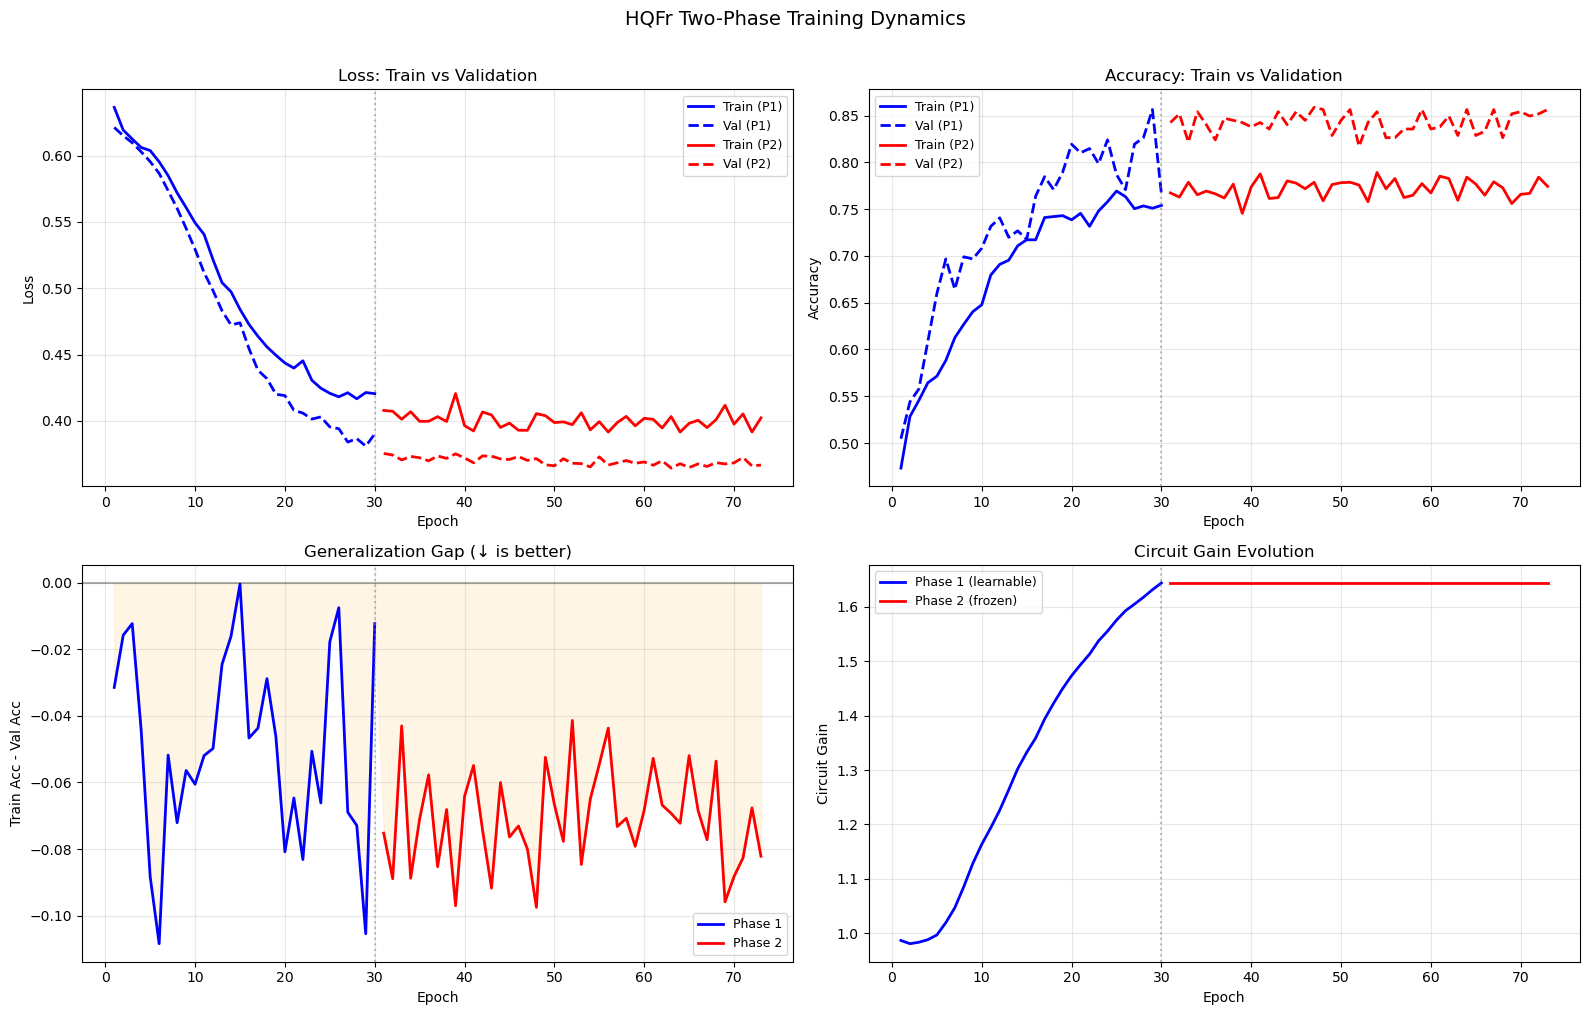

Phase 1: 30 epochs (classical pre-training)
Phase 2: 43 epochs (quantum fine-tuning, early stopped)
Final CG: 1.6440 | Optimal threshold: 0.42


In [18]:
# Two-Phase Training Visualization — Train vs Validation
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Combine Phase 1 + Phase 2
p1_train_loss = history["phase1"]["train_loss"]
p1_val_loss = history["phase1"]["val_loss"]
p1_train_acc = history["phase1"]["train_acc"]
p1_val_acc = history["phase1"]["val_acc"]
p1_qg = history["phase1"]["circuit_scale"]

p2_train_loss = history["phase2"]["train_loss"]
p2_val_loss = history["phase2"]["val_loss"]
p2_train_acc = history["phase2"]["train_acc"]
p2_val_acc = history["phase2"]["val_acc"]
p2_qg = history["phase2"]["circuit_scale"]

p1_epochs = range(1, len(p1_train_loss) + 1)
p2_epochs = range(len(p1_train_loss) + 1, len(p1_train_loss) + len(p2_train_loss) + 1)
p1_end = len(p1_train_loss)

# --- Top Left: Loss ---
axes[0, 0].plot(p1_epochs, p1_train_loss, "b-", linewidth=2, label="Train (P1)")
axes[0, 0].plot(p1_epochs, p1_val_loss, "b--", linewidth=2, label="Val (P1)")
axes[0, 0].plot(p2_epochs, p2_train_loss, "r-", linewidth=2, label="Train (P2)")
axes[0, 0].plot(p2_epochs, p2_val_loss, "r--", linewidth=2, label="Val (P2)")
axes[0, 0].axvline(x=p1_end, color="gray", linestyle=":", alpha=0.5)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss: Train vs Validation")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# --- Top Right: Accuracy ---
axes[0, 1].plot(p1_epochs, p1_train_acc, "b-", linewidth=2, label="Train (P1)")
axes[0, 1].plot(p1_epochs, p1_val_acc, "b--", linewidth=2, label="Val (P1)")
axes[0, 1].plot(p2_epochs, p2_train_acc, "r-", linewidth=2, label="Train (P2)")
axes[0, 1].plot(p2_epochs, p2_val_acc, "r--", linewidth=2, label="Val (P2)")
axes[0, 1].axvline(x=p1_end, color="gray", linestyle=":", alpha=0.5)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy: Train vs Validation")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# --- Bottom Left: Train-Val Gap (Overfitting Monitor) ---
p1_gap = [t - v for t, v in zip(p1_train_acc, p1_val_acc)]
p2_gap = [t - v for t, v in zip(p2_train_acc, p2_val_acc)]
axes[1, 0].plot(p1_epochs, p1_gap, "b-", linewidth=2, label="Phase 1")
axes[1, 0].plot(p2_epochs, p2_gap, "r-", linewidth=2, label="Phase 2")
axes[1, 0].axhline(y=0, color="k", linestyle="-", alpha=0.3)
axes[1, 0].axvline(x=p1_end, color="gray", linestyle=":", alpha=0.5)
axes[1, 0].fill_between(
    list(p1_epochs) + list(p2_epochs), p1_gap + p2_gap, 0, alpha=0.1, color="orange"
)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Train Acc - Val Acc")
axes[1, 0].set_title("Generalization Gap (↓ is better)")
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(alpha=0.3)

# --- Bottom Right: Circuit Gain ---
axes[1, 1].plot(p1_epochs, p1_qg, "b-", linewidth=2, label="Phase 1 (learnable)")
axes[1, 1].plot(p2_epochs, p2_qg, "r-", linewidth=2, label="Phase 2 (frozen)")
axes[1, 1].axvline(x=p1_end, color="gray", linestyle=":", alpha=0.5)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Circuit Gain")
axes[1, 1].set_title("Circuit Gain Evolution")
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.suptitle("HQFr Two-Phase Training Dynamics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Phase 1: {len(p1_train_loss)} epochs (classical pre-training)")
print(f"Phase 2: {len(p2_train_loss)} epochs (quantum fine-tuning, early stopped)")
print(f"Final CG: {p2_qg[-1]:.4f} | Optimal threshold: {history['best_threshold']:.2f}")

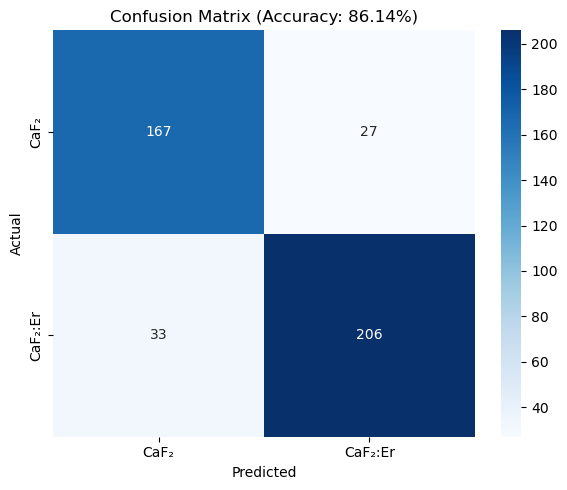

In [19]:
# Confusion matrix visualization
cm = metrics["confusion_matrix"]
cm_array = np.array([[cm["tn"], cm["fp"]], [cm["fn"], cm["tp"]]])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_array,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    xticklabels=["CaF₂", "CaF₂:Er"],
    yticklabels=["CaF₂", "CaF₂:Er"],
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (Accuracy: {metrics['accuracy'] * 100:.2f}%)")
plt.tight_layout()
plt.show()

## 6. Summary

In [20]:
print("=" * 50)
print("HQFr RESULTS SUMMARY")
print("=" * 50)
print("\nModel:")
print("  - Architecture: PreNN(3→3) → Quantum(3q,4L) → PostNN(9→16→1)")
print(f"  - Total params: {sum(p.numel() for p in model.parameters())}")
print(f"  - Circuit gain: {model.circuit_scale.item():.4f}")
print("\nThreshold-Dependent Metrics:")
print(f"  - Accuracy:  {metrics['accuracy'] * 100:.2f}%")
print(f"  - F1-Score:  {metrics['f1']:.4f}")
print(f"  - MCC:       {metrics['mcc']:.4f}")
print(f"  - Precision: {metrics['precision']:.4f}")
print(f"  - Recall:    {metrics['recall']:.4f}")
print(f"  - Threshold: {history['best_threshold']:.2f}")
print("=" * 50)

HQFr RESULTS SUMMARY

Model:
  - Architecture: PreNN(3→3) → Quantum(3q,4L) → PostNN(9→16→1)
  - Total params: 258
  - Circuit gain: 1.6440

Threshold-Dependent Metrics:
  - Accuracy:  86.14%
  - F1-Score:  0.8729
  - MCC:       0.7209
  - Precision: 0.8841
  - Recall:    0.8619
  - Threshold: 0.42
